# Used Car Price Prediction using Machine Learning

## 1.Problem Statement

The objective of this project is to develop a machine learning model that can accurately predict the selling price of used cars based on various features such as vehicle age, kilometers driven, fuel type, transmission type, engine capacity, mileage, brand, and model.

The used car market is highly dynamic, with prices influenced by multiple factors including vehicle condition, usage, and brand value. Accurately estimating a car’s price is challenging for both buyers and sellers due to the lack of transparent pricing standards.

This project aims to address this problem by building a data-driven predictive model that can estimate the fair market value of a used car. Multiple regression algorithms are evaluated and compared to identify the best-performing model, and the final model is used to build a prediction system where users can input car details and obtain an estimated selling price.

## 2.Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3.Load Dataset

In [2]:
df = pd.read_csv("cardekho_dataset.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## 4.Data understanding

In [3]:
df.shape

(15411, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [6]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

## 5.EDA & Preprocessing

In [7]:
numeric_df = df.select_dtypes(include=['int64','float64'])
numeric_df.head()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
0,0,9,120000,19.70,796,46.30,5,120000
1,1,5,20000,18.90,1197,82.00,5,550000
2,2,11,60000,17.00,1197,80.00,5,215000
3,3,9,37000,20.92,998,67.10,5,226000
4,4,6,30000,22.77,1498,98.59,5,570000


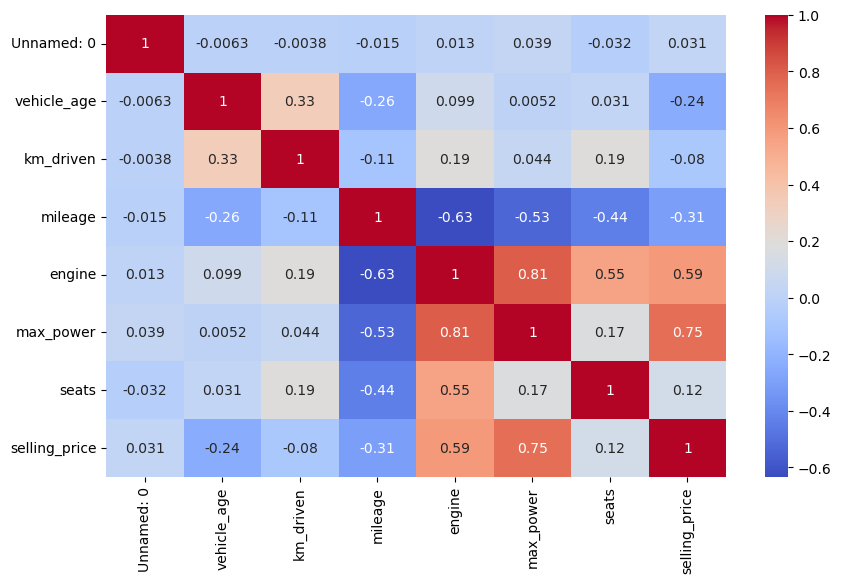

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [9]:
df.drop("Unnamed: 0", axis=1, inplace=True)

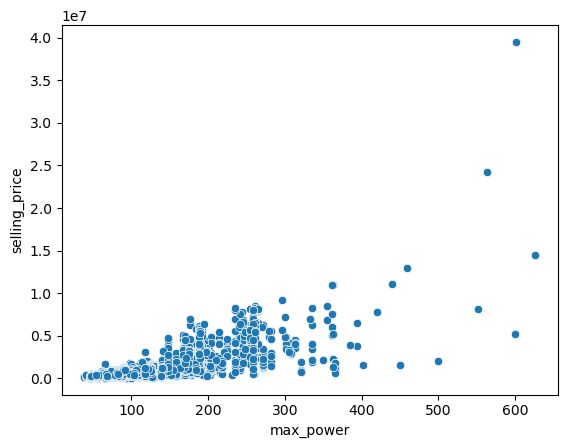

In [10]:
sns.scatterplot(x="max_power", y="selling_price", data=df)
plt.show()

In [11]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("Column:", col)
    print(df[col].unique())
    print()

Column: car_name
['Maruti Alto' 'Hyundai Grand' 'Hyundai i20' 'Ford Ecosport'
 'Maruti Wagon R' 'Hyundai i10' 'Hyundai Venue' 'Maruti Swift'
 'Hyundai Verna' 'Renault Duster' 'Mini Cooper' 'Maruti Ciaz'
 'Mercedes-Benz C-Class' 'Toyota Innova' 'Maruti Baleno'
 'Maruti Swift Dzire' 'Volkswagen Vento' 'Hyundai Creta' 'Honda City'
 'Mahindra Bolero' 'Toyota Fortuner' 'Renault KWID' 'Honda Amaze'
 'Hyundai Santro' 'Mahindra XUV500' 'Mahindra KUV100' 'Maruti Ignis'
 'Datsun RediGO' 'Mahindra Scorpio' 'Mahindra Marazzo' 'Ford Aspire'
 'Ford Figo' 'Maruti Vitara' 'Tata Tiago' 'Volkswagen Polo' 'Kia Seltos'
 'Maruti Celerio' 'Datsun GO' 'BMW 5' 'Honda CR-V' 'Ford Endeavour'
 'Mahindra KUV' 'Honda Jazz' 'BMW 3' 'Audi A4' 'Tata Tigor'
 'Maruti Ertiga' 'Tata Safari' 'Mahindra Thar' 'Tata Hexa'
 'Land Rover Rover' 'Maruti Eeco' 'Audi A6' 'Mercedes-Benz E-Class'
 'Audi Q7' 'BMW Z4' 'BMW 6' 'Jaguar XF' 'BMW X5' 'MG Hector' 'Honda Civic'
 'Isuzu D-Max' 'Porsche Cayenne' 'BMW X1' 'Skoda Rapid' 'Ford F

In [12]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [13]:
df.drop(['car_name'], axis=1, inplace=True)

In [15]:
luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Jaguar', 'Land', 'Jeep', 'Volvo', 'Porsche']

df['is_luxury'] = df['brand'].apply(lambda x: 1 if x in luxury_brands else 0)

In [16]:
df.select_dtypes(include='object').columns

Index(['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'], dtype='object')

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [18]:
df.head()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,is_luxury,brand_BMW,brand_Bentley,...,model_i10,model_i20,model_redi-GO,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,0,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,0,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,0,False,False,...,False,True,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,0,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,0,False,False,...,False,False,False,False,False,True,False,False,False,True


In [19]:
df.shape

(15411, 165)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Columns: 165 entries, vehicle_age to transmission_type_Manual
dtypes: bool(157), float64(2), int64(6)
memory usage: 3.2 MB


In [21]:
df['km_per_year'] = df['km_driven'] / (df['vehicle_age'] + 1)

## 6.Model training

In [22]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12328, 165)
X_test: (3083, 165)
y_train: (12328,)
y_test: (3083,)


## 7.Model comparison
### 7.1.( linear regression )

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [27]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
3334,190000,7.219775e+04
10928,600000,6.189561e+05
2518,665000,6.218158e+05
11322,1570000,1.212346e+06
9394,160000,-5.398450e+04
13649,675000,4.393357e+05
11892,465000,3.219935e+05
5133,260000,2.545438e+05
1611,300000,3.600293e+05
8137,850000,1.838792e+06


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 177547.75043941324
MSE: 150054000939.25607
RMSE: 387368.0432602257
R2 Score: 0.8006673343640037


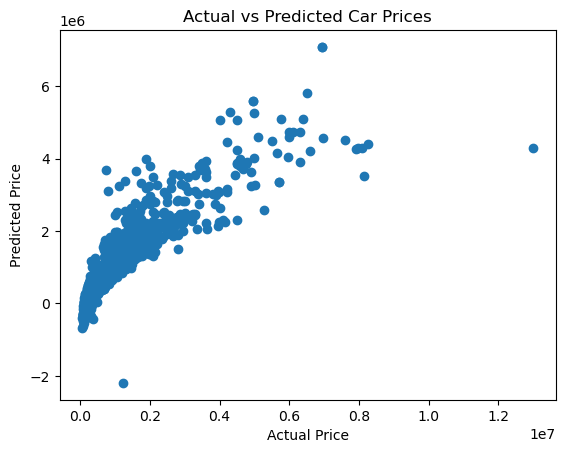

In [29]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

### 7.2. ( ridge regression )

In [30]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

Ridge()

In [31]:
y_pred_ridge = ridge_model.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test, y_pred_ridge)
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 186176.8135372557
RMSE: 394518.6144201737
R2 Score: 0.7932403000554709


### 7.3.( lasso Regression )

In [33]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.290e+14, tolerance: 9.998e+11
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.1)

In [34]:
y_pred_lasso = lasso_model.predict(X_test)

In [35]:
mae = mean_absolute_error(y_test, y_pred_lasso)
mse = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lasso)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 178459.40866612367
RMSE: 391434.2010437687
R2 Score: 0.7964606268591838


### 7.4.( elastic Net )

In [36]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_model.fit(X_train, y_train)

y_pred_elastic = elastic_model.predict(X_test)

In [37]:
mae = mean_absolute_error(y_test,y_pred_elastic)
mse = mean_squared_error(y_test, y_pred_elastic)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_elastic)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 246260.22381222798
RMSE: 474514.12946954306
R2 Score: 0.7008911986012492


### 7.5.( Decision tree regressor )

In [38]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [39]:
y_pred_dt = dt_model.predict(X_test)

In [40]:
mae = mean_absolute_error(y_test, y_pred_dt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2 = r2_score(y_test, y_pred_dt)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 129628.27602984106
RMSE: 372187.1216585981
R2 Score: 0.8159848507499174


### 7.6.(Random Forest Regressor)

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [42]:
y_pred_rf = rf_model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 99384.12408563973
RMSE: 219829.57837162958
R2 Score: 0.9358047124173544


#### feature_importance

In [44]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

max_power            0.654429
vehicle_age          0.132382
km_driven            0.044991
brand_Ferrari        0.030726
engine               0.023981
mileage              0.020513
model_GTC4Lusso      0.019063
km_per_year          0.016159
model_Ghost          0.005082
brand_Rolls-Royce    0.004483
dtype: float64

### 7.7.(Gradient Boosting Regressor)

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [46]:
y_pred_gb = gb_model.predict(X_test)

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 126477.38464052697
RMSE: 242100.23108182073
R2 Score: 0.922138762346725


### 7.8.( XG Boost Regressor )

In [48]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [49]:
y_pred_xgb = xgb_model.predict(X_test)

In [50]:
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 99163.15625
RMSE: 239411.9729671012
R2 Score: 0.9238582849502563


### 7.9.( LGBMRegressor )

In [51]:
from lightgbm import LGBMRegressor

In [52]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [53]:
lgb_model = LGBMRegressor(random_state=42)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1277
[LightGBM] [Info] Number of data points in the train set: 12328, number of used features: 99
[LightGBM] [Info] Start training from score 772120.619727


LGBMRegressor(random_state=42)

In [54]:
y_pred_lgb = lgb_model.predict(X_test)

In [55]:
mae = mean_absolute_error(y_test, y_pred_lgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2 = r2_score(y_test, y_pred_lgb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 102498.02799894077
RMSE: 222449.79905340972
R2 Score: 0.9342652628896101


### 7.10.( Cat Boost Regressor )

In [56]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [57]:
y_pred_cat = cat_model.predict(X_test)

In [58]:
mae = mean_absolute_error(y_test, y_pred_cat)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2 = r2_score(y_test, y_pred_cat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 93034.63274428538
RMSE: 179047.97637707184
R2 Score: 0.9574137176934814


### 8. Model Evaluation

In [59]:
params = cat_model.get_all_params()

print("Iterations:", params['iterations'])
print("Learning Rate:", params['learning_rate'])
print("Depth:", params['depth'])

Iterations: 1000
Learning Rate: 0.060888998210430145
Depth: 6


#### Get Feature Importance from CatBoost

In [58]:
import pandas as pd

feature_importance = cat_model.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
4,max_power,50.171928
0,vehicle_age,22.849828
1,km_driven,6.575675
3,engine,5.447451
2,mileage,2.182339
86,model_GTC4Lusso,1.149724
26,brand_Mercedes_Benz,1.135960
9,brand_Ferrari,1.086738
162,transmission_type_Manual,0.821049
158,fuel_type_Diesel,0.735154


### 9.Model saving

In [60]:
import joblib
joblib.dump(cat_model, "car_price_model.pklt")

['car_price_model.pklt']

In [61]:
joblib.dump(X_train.columns, "features.pklt")

['features.pklt']

In [62]:
import joblib
import pandas as pd

# Load model and features
model = joblib.load("car_price_model.pklt")
feature_columns = joblib.load("features.pklt")

print("===== Car Price Prediction =====\n")

# Numeric inputs
vehicle_age = int(input("Enter vehicle age (in years): "))
km_driven = int(input("Enter kilometers driven: "))
mileage = float(input("Enter mileage (km/l): "))
engine = int(input("Enter engine capacity (cc): "))
max_power = float(input("Enter max power (bhp): "))
seats = int(input("Enter number of seats: "))


# Helper function for menu selection
def choose_option(prompt, options):
    print(f"\n{prompt}")
    for i, option in enumerate(options, 1):
        print(f"{i}. {option}")
    
    choice = int(input("Enter choice number: "))
    return options[choice - 1]


# Categorical inputs with options

brand = input("\nEnter brand (e.g., Hyundai, BMW): ")
model_name = input("Enter model (e.g., Creta, i20): ")

seller_options = ["Individual", "Dealer", "Trustmark Dealer"]
seller_type = choose_option("Select seller type:", seller_options)

fuel_options = ["Petrol", "Diesel", "LPG", "Electric"]
fuel_type = choose_option("Select fuel type:", fuel_options)

transmission_options = ["Manual", "Automatic"]
transmission = choose_option("Select transmission type:", transmission_options)


# Create input dictionary
new_car = {
    "vehicle_age": vehicle_age,
    "km_driven": km_driven,
    "mileage": mileage,
    "engine": engine,
    "max_power": max_power,
    "seats": seats,
    "brand": brand,
    "model": model_name,
    "seller_type": seller_type,
    "fuel_type": fuel_type,
    "transmission_type": transmission
}


# Convert to DataFrame
input_df = pd.DataFrame([new_car])

# One-hot encoding
input_encoded = pd.get_dummies(input_df)

# Match training columns
input_encoded = input_encoded.reindex(columns=feature_columns, fill_value=0)

# Predict
predicted_price = model.predict(input_encoded)[0]

print("\n===== Result =====")
print(f"Predicted Selling Price: {round(predicted_price, 2)}")

===== Car Price Prediction =====



Enter vehicle age (in years):  3
Enter kilometers driven:  12000
Enter mileage (km/l):  12
Enter engine capacity (cc):  2999
Enter max power (bhp):  362
Enter number of seats:  5

Enter brand (e.g., Hyundai, BMW):  Mercedes-Benz
Enter model (e.g., Creta, i20):  S-Class S 450 4MATIC



Select seller type:
1. Individual
2. Dealer
3. Trustmark Dealer


Enter choice number:  2



Select fuel type:
1. Petrol
2. Diesel
3. LPG
4. Electric


Enter choice number:  1



Select transmission type:
1. Manual
2. Automatic


Enter choice number:  2



===== Result =====
Predicted Selling Price: 8444493.04
